In [2]:
import pandas as pd


In [3]:
df= pd.read_csv(r"D:\student-performance-prediction\Data\cleaned_student_data.csv")

In [4]:
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [6]:
x= df[['StudyTimeWeekly','Tutoring','Absences','ParentalSupport','Extracurricular','ParentalEducation']]
y=df['GPA']

In [7]:
x_train,x_test,y_train,y_test= train_test_split(x,y)

In [8]:
x_train

,StudyTimeWeekly,Tutoring,Absences,ParentalSupport,Extracurricular,ParentalEducation
545,18.616657,0,14,3,0,2
767,3.278405,0,1,0,0,1
1473,4.274734,0,13,1,0,2
1971,8.143286,0,22,2,1,2
1878,11.510990,0,27,1,0,1
...,...,...,...,...,...,...
806,13.765860,1,27,1,1,1
345,10.116184,0,12,3,0,3
1660,10.061366,1,7,3,1,2
2247,8.033063,1,25,2,1,1


In [9]:
len(x_train)


1794

In [10]:
len(x_test)

598

In [11]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:

y_pred=model.predict(x_test)


In [13]:
print(y_pred[:10])

[3.40361534 1.32678583 2.89787401 0.45733082 2.62312436 1.6372909
 1.69085703 1.75426697 2.07962955 1.13629178]


In [14]:
comparrison=pd.DataFrame(
    {
        'Actual':y_test,
        'Predicted':y_pred
    }
)

In [15]:
print(comparrison.head(10))

        Actual  Predicted
2025  3.748102   3.403615
1223  1.193618   1.326786
748   2.772163   2.897874
224   0.768316   0.457331
2260  2.401374   2.623124
282   1.633679   1.637291
684   1.592388   1.690857
2085  1.376381   1.754267
1847  1.977538   2.079630
1049  1.391788   1.136292


In [16]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print('R2 score:',r2)

R2 score: 0.9416471672219332


In [17]:
import joblib
joblib.dump(model,'gpa_model.pkl')


['gpa_model.pkl']

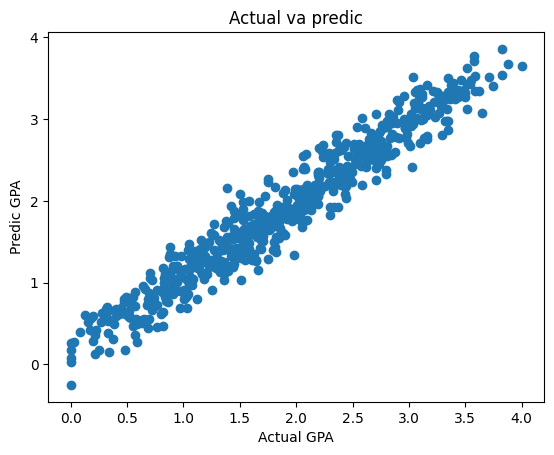

In [18]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel('Actual GPA')
plt.ylabel('Predic GPA')
plt.title('Actual va predic')

plt.show()